<a href="https://colab.research.google.com/github/muajnstu/Airlines_Review_Analysis_and_Topic_Modelling/blob/main/Sentiment_Aware_Topic_Modeling_(D2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Library Installation**

In [ ]:
!pip install -q bertopic
!pip install -q sentence-transformers
!pip install -q umap-learn hdbscan
!pip install -q wordcloud gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.4 MB/s eta 0:00:00


**All imports in one place**

In [ ]:
import re
import requests
import pickle
from io import BytesIO
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

# NLP preprocessing
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)

# Sklearn
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score

# Topic modeling
from bertopic import BERTopic
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from umap import UMAP

# Topic evaluation
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# Visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
from wordcloud import WordCloud
from google.colab import drive


**Content of Best Performing Model from Sentiment Classification Module**

In [ ]:
# raw_content_of_best_performing_model
BASE_URL = "https://raw.githubusercontent.com/muajnstu/AirSerReview_subfiles/main/merged_data_d2/"

TFIDF_PATH = BASE_URL + "tfidf_vectorizer.pkl"
SVD_PATH = BASE_URL + "svd_lsa.pkl"
SCALER_PATH = BASE_URL + "scaler.pkl"
LE_PATH = BASE_URL + "label_encoder.pkl"
MODEL_PATH = BASE_URL + "best_model.pkl"

**All tunable constants in one place.**

In [ ]:
RANDOM_STATE = 42

DATASET_URL = ("https://raw.githubusercontent.com/muajnstu/Plan_Crash_Prediction_-_Topic_Modelling/refs/heads/main/Dataset_2.csv")
REVIEW_COL = "review"
LABEL_COL  = "sentiment"
TEXT_COL   = "cleaned_text"

SENTIMENT_CLASSES = ["Positive", "Negative", "Mixed"]

TFIDF_PATH  = "tfidf_vectorizer.pkl"
SVD_PATH    = "svd_lsa.pkl"
SCALER_PATH = "scaler.pkl"
LE_PATH     = "label_encoder.pkl"
MODEL_PATH  = "best_model.pkl"

# — BERTopic
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
UMAP_N_COMPONENTS    = 3
BERTOPIC_TOP_WORDS   = 10

HDBSCAN_MIN_CLUSTER_POS = 5
HDBSCAN_MIN_CLUSTER_NEG = 7
HDBSCAN_MIN_CLUSTER_MIX = 3

#— visualisation
TOP_N_TOPICS_TO_PLOT = 5
TOP_N_WORDS_PLOT     = 10

# report
DOMINANT_TOPIC_N   = 5
INSIGHT_TOP_N      = 3
REPORT_OUTPUT_FILE = "sentiment_topic_report.txt"

SENTIMENT_COLORS = {
    "Positive": "#2ecc71",
    "Negative": "#e74c3c",
    "Mixed":    "#f39c12",
}

**Helper Functions**

All reusable logic defined here before any step executes.


In [ ]:
_stop_words = set(stopwords.words("english"))
_lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    # Lowercase -> strip non-alpha -> remove stopwords -> lemmatise
    text   = str(text).lower()
    text   = re.sub(r"[^a-z\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [_lemmatizer.lemmatize(w) for w in tokens if w not in _stop_words]
    return " ".join(tokens)


In [ ]:
def load_artifacts():
    # Download and load from GitHub
    tfidf = pickle.load(BytesIO(requests.get(TFIDF_PATH).content))
    svd = pickle.load(BytesIO(requests.get(SVD_PATH).content))
    scaler = pickle.load(BytesIO(requests.get(SCALER_PATH).content))
    le = pickle.load(BytesIO(requests.get(LE_PATH).content))
    model = pickle.load(BytesIO(requests.get(MODEL_PATH).content))

    print("Artifacts loaded:")
    print(f"  TF-IDF  : vocab size {len(tfidf.vocabulary_):,}, max_features={tfidf.max_features}")
    print(f"  LSA     : {svd.n_components} components")
    print(f"  Scaler  : input dim {scaler.mean_.shape[0]}")
    print(f"  Encoder : classes = {list(le.classes_)}")
    print(f"  Model   : {type(model).__name__}")
    return tfidf, svd, scaler, le, model

In [ ]:
def build_bertopic_model(n_docs: int, embedding_model: SentenceTransformer,
                         min_topic_size: int = HDBSCAN_MIN_CLUSTER_POS) -> BERTopic:
    # n_neighbors via square-root heuristic (floored at 10)
    n_neighbors = max(10, int(round(n_docs ** 0.5)))
    print(f"  n_docs={n_docs:,}  ->  UMAP n_neighbors={n_neighbors}")
    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=UMAP_N_COMPONENTS,
        metric="cosine",
        random_state=RANDOM_STATE,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=min_topic_size,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )
    return BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        top_n_words=BERTOPIC_TOP_WORDS,
        verbose=True,
    )

In [ ]:
def compute_coherence(topic_model: BERTopic, texts: list) -> float:
    tokenized   = [t.lower().split() for t in texts]
    dictionary  = Dictionary(tokenized)
    topic_words = [[w for w, _ in topic_model.get_topic(t)]
                   for t in topic_model.get_topics() if t != -1]
    if not topic_words:
        return float("nan")
    return CoherenceModel(topics=topic_words, texts=tokenized,
                          dictionary=dictionary, coherence="c_v").get_coherence()


def compute_diversity(topic_model: BERTopic, top_n: int = 10) -> float:
    all_words, unique_words = [], set()
    for t in topic_model.get_topics():
        if t == -1: continue
        words = [w for w, _ in topic_model.get_topic(t)][:top_n]
        all_words.extend(words)
        unique_words.update(words)
    return len(unique_words) / len(all_words) if all_words else 0.0


def compute_silhouette(topic_model: BERTopic, texts: list) -> float:
    # Access the underlying SentenceTransformer object to call encode
    embeddings = topic_model.embedding_model.embedding_model.encode(texts, show_progress_bar=False)
    reduced    = topic_model.umap_model.transform(embeddings)
    labels_arr = np.array(list(topic_model.hdbscan_model.labels_))
    mask       = labels_arr != -1
    if mask.sum() < 2 or len(set(labels_arr[mask])) < 2:
        return float("nan")
    return silhouette_score(reduced[mask], labels_arr[mask])


def evaluate_topic_models(models_dict: dict) -> pd.DataFrame:
    results = {}
    for name, (model_t, texts) in models_dict.items():
        print(f"  Evaluating {name} ...")
        coh = compute_coherence(model_t, texts)
        div = compute_diversity(model_t)
        sil = compute_silhouette(model_t, texts)
        n_t = len(model_t.get_topic_info()) - 1
        results[name] = {"Coherence (C_V)": round(coh, 4),
                         "Diversity":       round(div, 4),
                         "Silhouette":      round(sil, 4),
                         "# Topics":        n_t}
        print(f"    Coherence={coh:.4f}  Diversity={div:.4f}  "
              f"Silhouette={sil:.4f}  Topics={n_t}")
    return pd.DataFrame(results).T

In [ ]:
def plot_wordclouds(topic_model, sentiment, top_n_topics=TOP_N_TOPICS_TO_PLOT):
    info      = topic_model.get_topic_info()
    topic_ids = [t for t in info["Topic"].tolist() if t != -1][:top_n_topics]
    cols      = min(len(topic_ids), 3)
    rows      = (len(topic_ids) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes      = np.array(axes).flatten()
    for ax, tid in zip(axes, topic_ids):
        freq = {w: s for w, s in topic_model.get_topic(tid)}
        wc   = WordCloud(width=400, height=300,
                         background_color="white").generate_from_frequencies(freq)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"Topic {tid}", fontsize=12)
        ax.axis("off")
    for ax in axes[len(topic_ids):]: ax.axis("off")
    fig.suptitle(f"Word Clouds - {sentiment} Sentiment", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"wordclouds_{sentiment.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_mds(topic_model, sentiment):
    info   = topic_model.get_topic_info()
    topics = [t for t in info["Topic"].tolist() if t != -1]
    if len(topics) < 3:
        print(f"  Skipping MDS for {sentiment}: need >= 3 topics (found {len(topics)}).")
        return
    vecs = []
    for t in topics:
        words = [w for w, _ in topic_model.get_topic(t)]
        embs  = topic_model.embedding_model.embedding_model.encode(words, show_progress_bar=False)
        vecs.append(embs.mean(axis=0))
    coords = MDS(n_components=2, random_state=RANDOM_STATE,
                 dissimilarity="euclidean").fit_transform(np.array(vecs))
    counts = info.set_index("Topic")["Count"]
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(coords[:, 0], coords[:, 1],
               s=[counts.get(t, 20) / 2 for t in topics],
               c=range(len(topics)), cmap="tab20", alpha=0.8)
    for i, t in enumerate(topics):
        ax.annotate(f"T{t}", (coords[i, 0], coords[i, 1]),
                    fontsize=9, ha="center", va="bottom")
    ax.set_title(f"Topic Distance Map (MDS) - {sentiment}", fontsize=14)
    ax.set_xlabel("MDS Dim 1"); ax.set_ylabel("MDS Dim 2")
    plt.tight_layout()
    plt.savefig(f"mds_{sentiment.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_topic_hierarchy(topic_model, sentiment, texts):
    try:
        h = topic_model.hierarchical_topics(texts)
        fig = topic_model.visualize_hierarchy(hierarchical_topics=h,
                                              title=f"Topic Hierarchy - {sentiment}")
        fig.write_image(f"hierarchy_{sentiment.lower()}.png")
        fig.show()
    except Exception as exc:
        print(f"  Hierarchy skipped for {sentiment}: {exc}")


def plot_top_words(topic_model, sentiment,
                   top_n_topics=TOP_N_TOPICS_TO_PLOT, top_n_words=TOP_N_WORDS_PLOT):
    info      = topic_model.get_topic_info()
    topic_ids = [t for t in info["Topic"].tolist() if t != -1][:top_n_topics]
    cols      = min(len(topic_ids), 3)
    rows      = (len(topic_ids) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 4 * rows))
    axes      = np.array(axes).flatten()
    for ax, tid in zip(axes, topic_ids):
        pairs  = topic_model.get_topic(tid)[:top_n_words]
        words  = [p[0] for p in pairs][::-1]
        scores = [p[1] for p in pairs][::-1]
        ax.barh(words, scores, color="steelblue")
        ax.set_title(f"Topic {tid}", fontsize=11)
        ax.set_xlabel("c-TF-IDF score")
    for ax in axes[len(topic_ids):]: ax.axis("off")
    fig.suptitle(f"Top Words per Topic - {sentiment}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"topwords_{sentiment.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
def print_dominant_topics(topic_model, sentiment, top_n=DOMINANT_TOPIC_N):
    info = topic_model.get_topic_info()
    top  = info[info["Topic"] != -1].nlargest(top_n, "Count")
    print(f"\n-- Dominant Topics - {sentiment} --")
    for _, row in top.iterrows():
        words = ", ".join([w for w, _ in topic_model.get_topic(row["Topic"])][:7])
        print(f"  Topic {int(row['Topic']):3d} | Count {int(row['Count']):5d} | {words}")


def extract_insights(topic_model, sentiment, top_n=INSIGHT_TOP_N):
    info  = topic_model.get_topic_info()
    real  = info[info["Topic"] != -1].nlargest(top_n, "Count")
    total = real["Count"].sum()
    rows  = []
    for _, row in real.iterrows():
        words = [w for w, _ in topic_model.get_topic(row["Topic"])][:5]
        pct   = 100 * row["Count"] / total if total else 0
        rows.append({"Sentiment": sentiment,
                     "Topic":     int(row["Topic"]),
                     "Doc Count": int(row["Count"]),
                     "% Share":   round(pct, 1),
                     "Key Words": ", ".join(words)})
    return rows


mpl.rcParams.update({
    "font.family":  "serif",
    "font.serif":   ["Times New Roman", "DejaVu Serif"],
    "figure.dpi":   300,
    "savefig.dpi":  300,
})

def plot_table(df_table, title, filename, header_color="#2166AC"):
    n_rows, n_cols = df_table.shape
    fig_h = 0.32 * (n_rows + 2)
    fig_w = 2.2  * n_cols + 1.2

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    cell_text  = df_table.values.tolist()
    row_labels = list(df_table.index)
    col_labels = list(df_table.columns)

    table = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc="left",
        rowLoc="left",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(7.5)
    table.scale(1, 1.38)

    # Header row
    for col_idx in range(n_cols):
        cell = table[0, col_idx]
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", fontweight="bold")
        cell.set_edgecolor("#cccccc")

    # Last column bold (theme label column)
    for row_idx in range(1, n_rows + 1):
        cell = table[row_idx, -1]
        cell.set_facecolor("#f0f0f0")
        cell.set_text_props(fontweight="bold", color="#333333")
        cell.set_edgecolor("#cccccc")

    # Alternating row shading
    for row_idx in range(1, n_rows + 1):
        for col_idx in range(n_cols):
            cell = table[row_idx, col_idx]
            cell.set_facecolor("#ffffff" if row_idx % 2 == 0 else "#f9f9f9")
            cell.set_edgecolor("#dddddd")

    ax.set_title(title, fontsize=9, fontweight="bold",
                 loc="left", pad=8, color="#222222")

    plt.tight_layout()
    plt.savefig(f"{filename}.pdf", bbox_inches="tight")
    plt.savefig(f"{filename}.png", bbox_inches="tight")
    plt.show()
    print(f"{filename} saved ✓")


def plot_cross_sentiment_distribution(models_dict):
    summary_rows = {}
    for sent, (model_t, _) in models_dict.items():
        info = model_t.get_topic_info()
        real = info[info["Topic"] != -1]
        summary_rows[sent] = {
            "# Topics":            len(real),
            "Total Docs Assigned": real["Count"].sum(),
            "Outlier Docs":        info.loc[info["Topic"] == -1, "Count"].sum(),
        }
    summary_df = pd.DataFrame(summary_rows).T
    print("-- Cross-Sentiment Summary --")
    print(summary_df.to_string())
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (sent, (model_t, _)) in zip(axes, models_dict.items()):
        info = model_t.get_topic_info()
        real = info[info["Topic"] != -1].nlargest(10, "Count")
        ax.bar([f"T{t}" for t in real["Topic"]], real["Count"],
               color=SENTIMENT_COLORS.get(sent, "steelblue"))
        ax.set_title(f"{sent} - Topic Counts", fontsize=12)
        ax.set_xlabel("Topic"); ax.set_ylabel("Document Count")
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.suptitle("Cross-Sentiment Topic Distribution", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("cross_sentiment_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    return summary_df


def build_theme_df(topic_model, texts, top_n_words=8):
    """
    Extracts per-topic summary into a DataFrame ready for plot_journal_table.
    Columns: Topic | Documents | Top Words | Theme
    'Theme' is an auto-label: the top 3 words joined — you can manually
    rename these after printing to give them proper thematic names.
    """
    info = topic_model.get_topic_info()
    info = info[info["Topic"] != -1].reset_index(drop=True)  # drop outlier row

    rows = []
    for _, row in info.iterrows():
        tid   = int(row["Topic"])
        count = int(row["Count"])
        words = topic_model.get_topic(tid)[:top_n_words]
        top_words_str = ", ".join([w for w, _ in words])
        # Auto theme label from top 3 words — rename manually
        theme_label = " / ".join([w for w, _ in words[:3]]).title()
        rows.append({
            "Topic":     f"Topic {tid}",
            "Docs":      count,
            "Top Words": top_words_str,
            "Theme":     theme_label,
        })

    df = pd.DataFrame(rows).set_index("Topic")
    return df


def generate_report(eval_df, models_dict, insights_df,
                    output_path=REPORT_OUTPUT_FILE):
    sep   = "=" * 70
    lines = [sep, "  SENTIMENT-AWARE TOPIC ANALYSIS REPORT", sep]
    lines.append("\n[1] TOPIC MODEL QUALITY METRICS")
    lines.append(eval_df.to_string())
    for sent, (model_t, _) in models_dict.items():
        lines.append(f"\n[2] DOMINANT TOPICS - {sent.upper()}")
        info = model_t.get_topic_info()
        real = info[info["Topic"] != -1].nlargest(5, "Count")
        for _, row in real.iterrows():
            words = ", ".join([w for w, _ in model_t.get_topic(row["Topic"])][:6])
            lines.append(f"  Topic {int(row['Topic']):3d}: {words}  (n={int(row['Count'])})")
    lines.append("\n[3] KEY INSIGHTS & RECOMMENDATIONS")
    for sent in ["Positive", "Negative", "Mixed"]:
        rows = insights_df[insights_df["Sentiment"] == sent]
        if not rows.empty:
            t = rows.iloc[0]
            lines.append(f"  * Largest {sent.upper()} theme : [{t['Key Words']}] ({t['% Share']}%)")
    lines += [
        "  * Action: Address dominant NEGATIVE topics to reduce churn/complaints.",
        "  * Action: Amplify POSITIVE topics in marketing & communications.",
        "  * Action: Investigate MIXED themes for ambiguous customer signals.",
        sep,
    ]
    report_text = "\n".join(lines)
    print(report_text)
    with open(output_path, "w") as f:
        f.write(report_text)
    print(f"\n[Report saved -> {output_path}]")


print("All helper functions defined.")


All helper functions defined.


**Sentiment Prediction**

Load the artifacts of best performing model and predict sentiment labels for the **entire original dataset**. No retraining. The feature pipeline (TF-IDF -> SVD -> Scaler) uses transform() only — all parameters are frozen from previous notebook


In [ ]:
df = pd.read_csv(DATASET_URL)
df = df.drop_duplicates().reset_index(drop=True)
df[TEXT_COL] = df[REVIEW_COL].apply(clean_text)
print(f"Dataset loaded and cleaned: {len(df):,} rows")
print("Sentiment distribution:")
print(df[LABEL_COL].value_counts())


Dataset loaded and cleaned: 7,077 rows
Sentiment distribution:
sentiment
Negative    3494
Positive    2037
Mixed       1546
Name: count, dtype: int64


In [ ]:
tfidf, svd, scaler, le, best_model = load_artifacts()

Artifacts loaded:
  TF-IDF  : vocab size 1,000, max_features=1000
  LSA     : 100 components
  Scaler  : input dim 100
  Encoder : classes = ['Mixed', 'Negative', 'Positive']
  Model   : MLPClassifier


In [ ]:
X_tfidf  = tfidf.transform(df[TEXT_COL])
X_lsa    = svd.transform(X_tfidf)
X_scaled = scaler.transform(X_lsa)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"  ({X_scaled.shape[0]:,} documents x {X_scaled.shape[1]} LSA components)")


Feature matrix shape: (7077, 100)
  (7,077 documents x 100 LSA components)


In [ ]:
proba  = best_model.predict_proba(X_scaled)
pred_y = best_model.predict(X_scaled)
conf   = proba[np.arange(len(pred_y)), pred_y]

df["predicted_sentiment"] = le.inverse_transform(pred_y)
df["confidence"]          = conf

print("Predicted sentiment distribution (full corpus):")
print(df["predicted_sentiment"].value_counts())
print("\nConfidence statistics (informational only — not used for filtering):")
print(df["confidence"].describe().round(3))

df_filtered = df.copy()

print(f"\nTotal corpus retained : {len(df_filtered):,} (100%)")
print("\nFinal distribution:")
print(df_filtered["predicted_sentiment"].value_counts())

Predicted sentiment distribution (full corpus):
predicted_sentiment
Negative    3587
Mixed       2009
Positive    1481
Name: count, dtype: int64

Confidence statistics (informational only — not used for filtering):
count    7077.000
mean        0.988
std         0.058
min         0.467
25%         0.999
50%         1.000
75%         1.000
max         1.000
Name: confidence, dtype: float64

Total corpus retained : 7,077 (100%)

Final distribution:
predicted_sentiment
Negative    3587
Mixed       2009
Positive    1481
Name: count, dtype: int64


Partition the predictions into three text lists.
Labels Positive / Negative / Mixed


In [ ]:
pos_texts = df_filtered.loc[
    df_filtered["predicted_sentiment"] == "Positive", TEXT_COL].tolist()

neg_texts = df_filtered.loc[
    df_filtered["predicted_sentiment"] == "Negative", TEXT_COL].tolist()

mix_texts = df_filtered.loc[
    df_filtered["predicted_sentiment"] == "Mixed", TEXT_COL].tolist()

print(f"Positive texts : {len(pos_texts):,}")
print(f"Negative texts : {len(neg_texts):,}")
print(f"Mixed    texts : {len(mix_texts):,}")


Positive texts : 1,481
Negative texts : 3,587
Mixed    texts : 2,009


**Topic Modeling with BERTopic (per Sentiment)**

BERTopic is run independently on each of the three sentiment groups.
A single SentenceTransformer is loaded once and shared across all three runs.


In [ ]:
# Load shared embedding model once
print("Loading sentence embedding model ...")
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
print("Embedding model ready.")


Loading sentence embedding model ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model ready.


In [ ]:
# BERTopic on POSITIVE texts
print("=" * 60)
print("BERTopic on POSITIVE texts ...")
print("=" * 60)
topic_model_pos = build_bertopic_model(len(pos_texts), embedding_model)
topics_pos, probs_pos = topic_model_pos.fit_transform(pos_texts)
pos_info = topic_model_pos.get_topic_info()
print(f"\nPositive - {len(pos_info) - 1} topics discovered")
print(pos_info.head(10).to_string(index=False))


2026-05-17 10:05:51,774 - BERTopic - Embedding - Transforming documents to embeddings.


BERTopic on POSITIVE texts ...
  n_docs=1,481  ->  UMAP n_neighbors=38


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

2026-05-17 10:07:00,075 - BERTopic - Embedding - Completed ✓
2026-05-17 10:07:00,077 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-17 10:07:18,757 - BERTopic - Dimensionality - Completed ✓
2026-05-17 10:07:18,759 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-17 10:07:18,820 - BERTopic - Cluster - Completed ✓
2026-05-17 10:07:18,828 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-17 10:07:18,943 - BERTopic - Representation - Completed ✓



Positive - 7 topics discovered
 Topic  Count                              Name                                                                     Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [ ]:
# BERTopic on NEGATIVE texts
print("=" * 60)
print("BERTopic on NEGATIVE texts ...")
print("=" * 60)
topic_model_neg = build_bertopic_model(len(neg_texts), embedding_model)
topics_neg, probs_neg = topic_model_neg.fit_transform(neg_texts)
neg_info = topic_model_neg.get_topic_info()
print(f"\nNegative - {len(neg_info) - 1} topics discovered")
print(neg_info.head(10).to_string(index=False))


2026-05-17 10:08:29,310 - BERTopic - Embedding - Transforming documents to embeddings.


BERTopic on NEGATIVE texts ...
  n_docs=3,587  ->  UMAP n_neighbors=60


Batches:   0%|          | 0/113 [00:00<?, ?it/s]

2026-05-17 10:11:08,841 - BERTopic - Embedding - Completed ✓
2026-05-17 10:11:08,842 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-17 10:11:40,499 - BERTopic - Dimensionality - Completed ✓
2026-05-17 10:11:40,500 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-17 10:11:40,632 - BERTopic - Cluster - Completed ✓
2026-05-17 10:11:40,638 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-17 10:11:40,920 - BERTopic - Representation - Completed ✓



Negative - 6 topics discovered
 Topic  Count                            Name                                                                Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [ ]:
# BERTopic on MIXED texts
print("=" * 60)
print("BERTopic on MIXED texts ...")
print("=" * 60)
topic_model_mix = build_bertopic_model(len(mix_texts), embedding_model)
topics_mix, probs_mix = topic_model_mix.fit_transform(mix_texts)
mix_info = topic_model_mix.get_topic_info()
print(f"\nMixed - {len(mix_info) - 1} topics discovered")
print(mix_info.head(10).to_string(index=False))


2026-05-17 10:11:41,298 - BERTopic - Embedding - Transforming documents to embeddings.


BERTopic on MIXED texts ...
  n_docs=2,009  ->  UMAP n_neighbors=45


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-05-17 10:12:56,195 - BERTopic - Embedding - Completed ✓
2026-05-17 10:12:56,200 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-17 10:13:08,003 - BERTopic - Dimensionality - Completed ✓
2026-05-17 10:13:08,004 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-17 10:13:08,078 - BERTopic - Cluster - Completed ✓
2026-05-17 10:13:08,084 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-17 10:13:08,191 - BERTopic - Representation - Completed ✓



Mixed - 2 topics discovered
 Topic  Count                              Name                                                                   Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

**Topic Evaluation & Interpretation**

In [ ]:
models_dict = {
    "Positive": (topic_model_pos, pos_texts),
    "Negative": (topic_model_neg, neg_texts),
    "Mixed":    (topic_model_mix, mix_texts),
}

print("Computing topic quality metrics ...")
eval_df = evaluate_topic_models(models_dict)
print("\n-- Topic Quality Summary --")
print(eval_df.to_string())


Computing topic quality metrics ...
  Evaluating Positive ...
    Coherence=0.4912  Diversity=0.5571  Silhouette=0.5897  Topics=7
  Evaluating Negative ...
    Coherence=0.4882  Diversity=0.6500  Silhouette=0.3250  Topics=6
  Evaluating Mixed ...
    Coherence=0.4324  Diversity=0.6000  Silhouette=0.5898  Topics=2

-- Topic Quality Summary --
          Coherence (C_V)  Diversity  Silhouette  # Topics
Positive           0.4912     0.5571      0.5897       7.0
Negative           0.4882     0.6500      0.3250       6.0
Mixed              0.4324     0.6000      0.5898       2.0


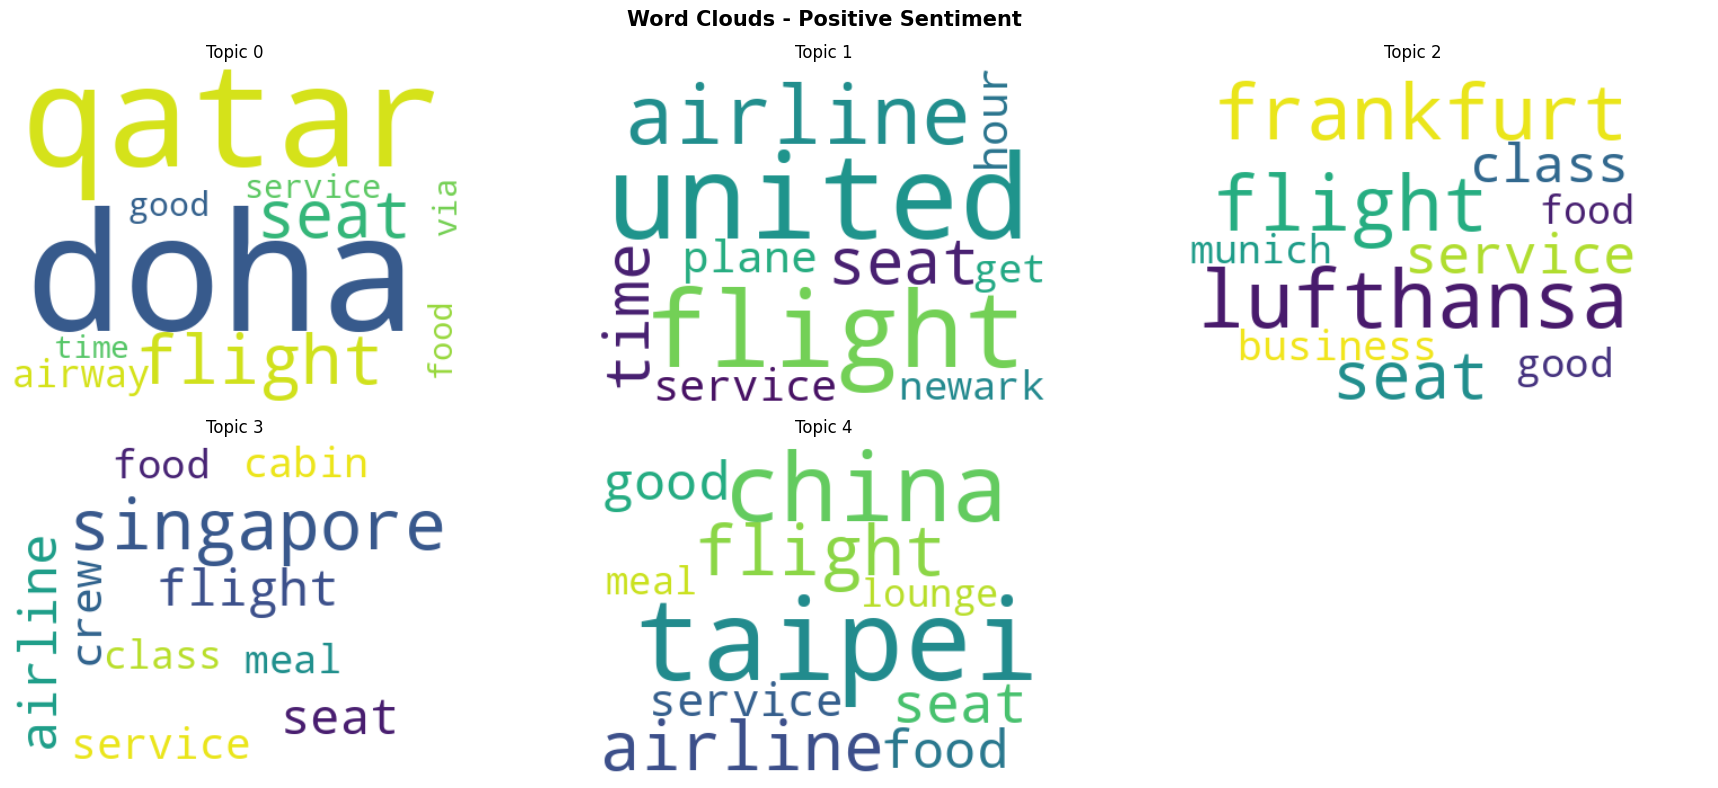

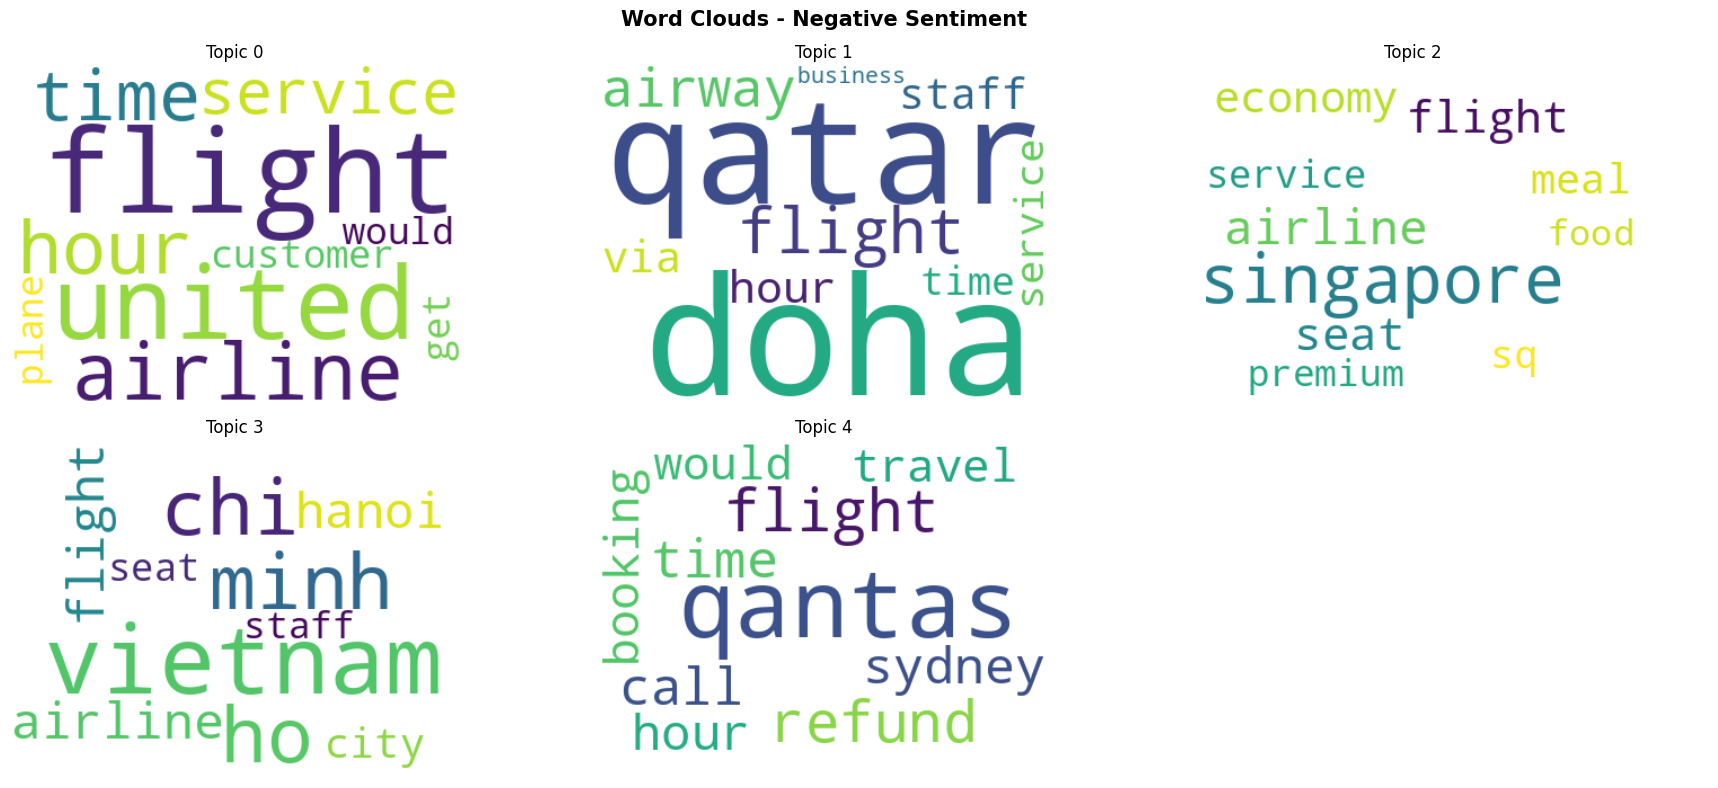

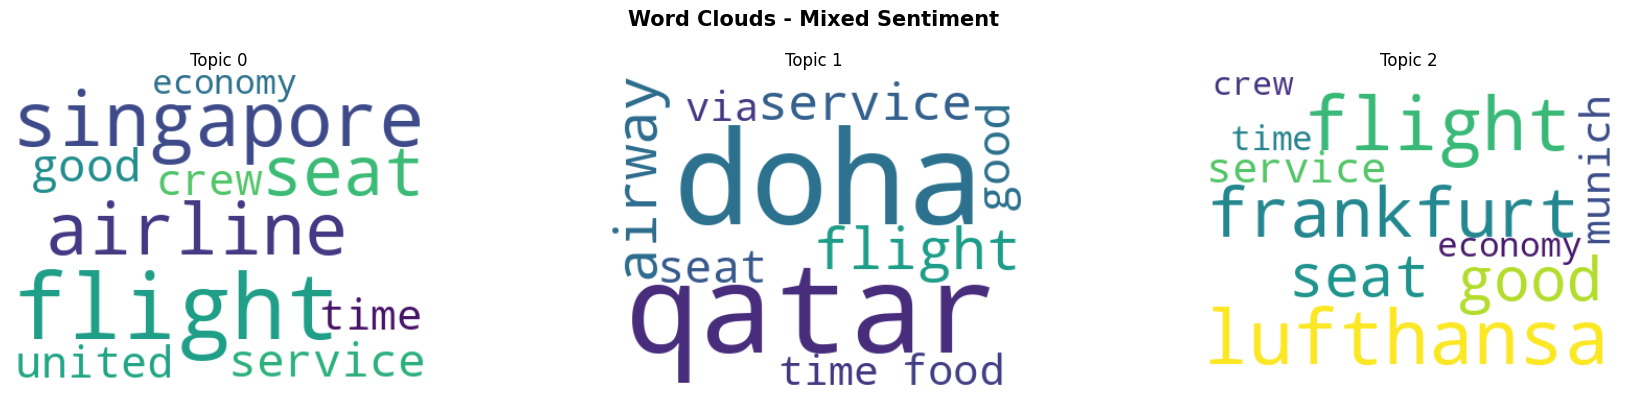

In [ ]:
# Word Clouds
for sentiment, (model_t, _) in models_dict.items():
    plot_wordclouds(model_t, sentiment)


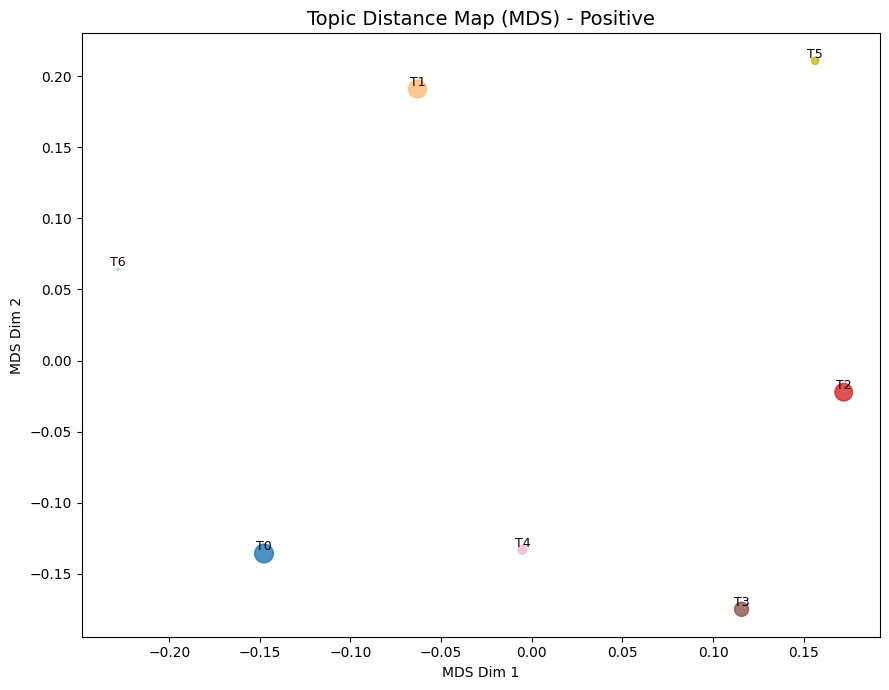

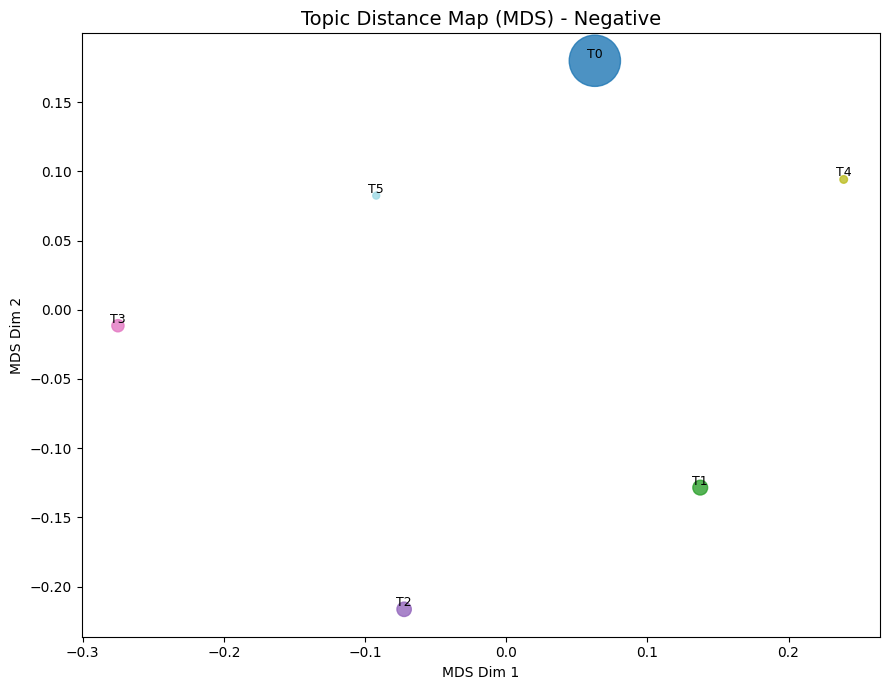

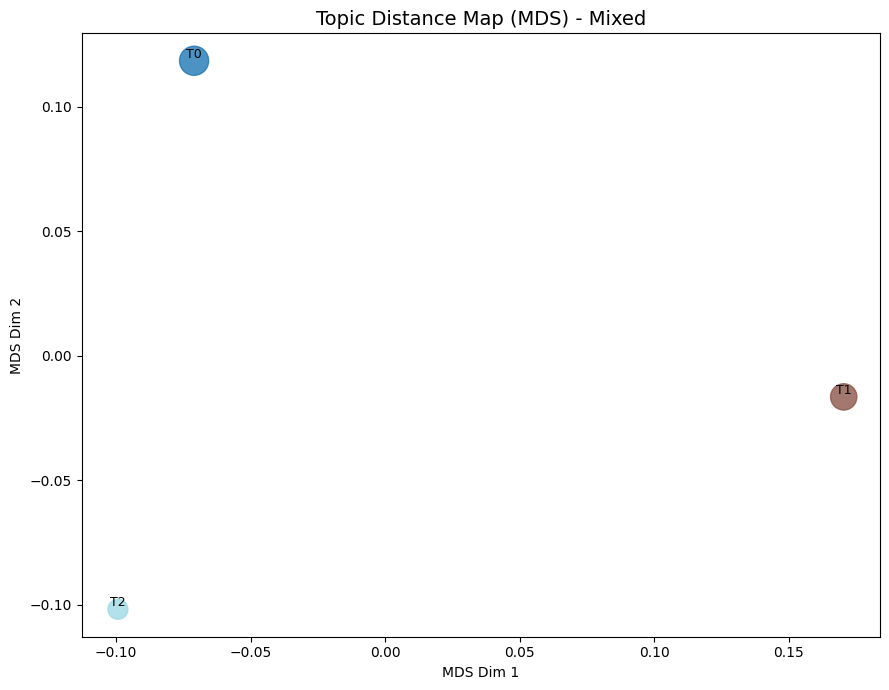

In [ ]:
# 7c. Topic Distance Map (MDS)
for sentiment, (model_t, _) in models_dict.items():
    plot_mds(model_t, sentiment)


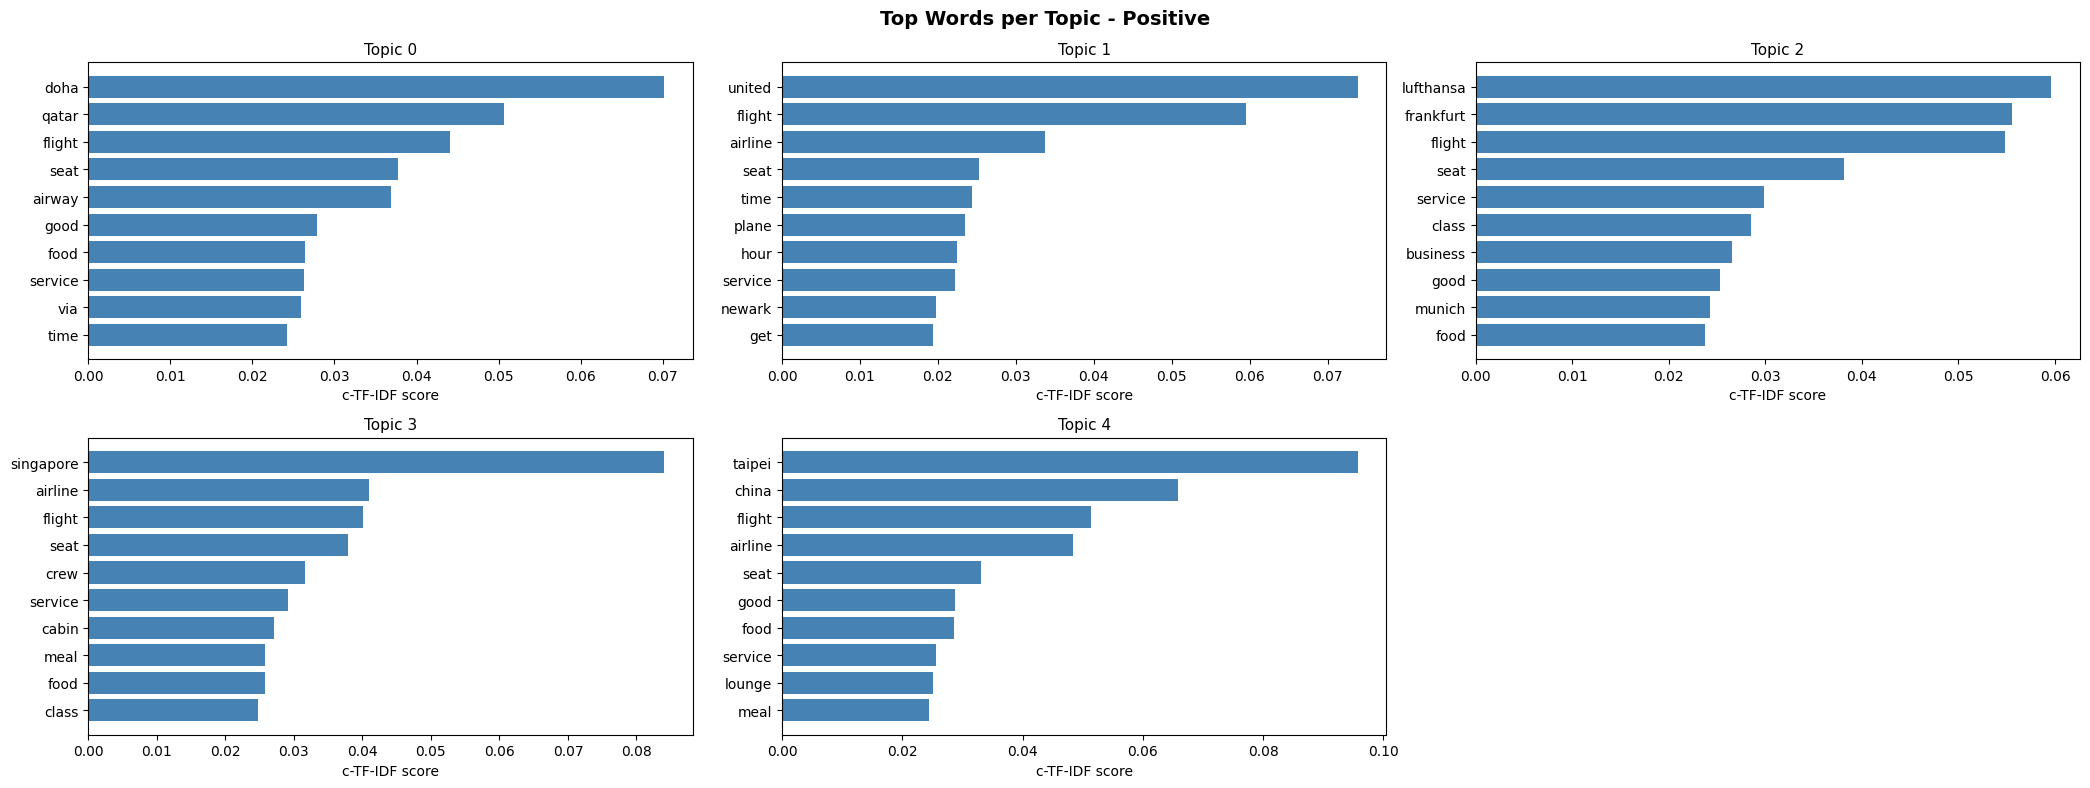

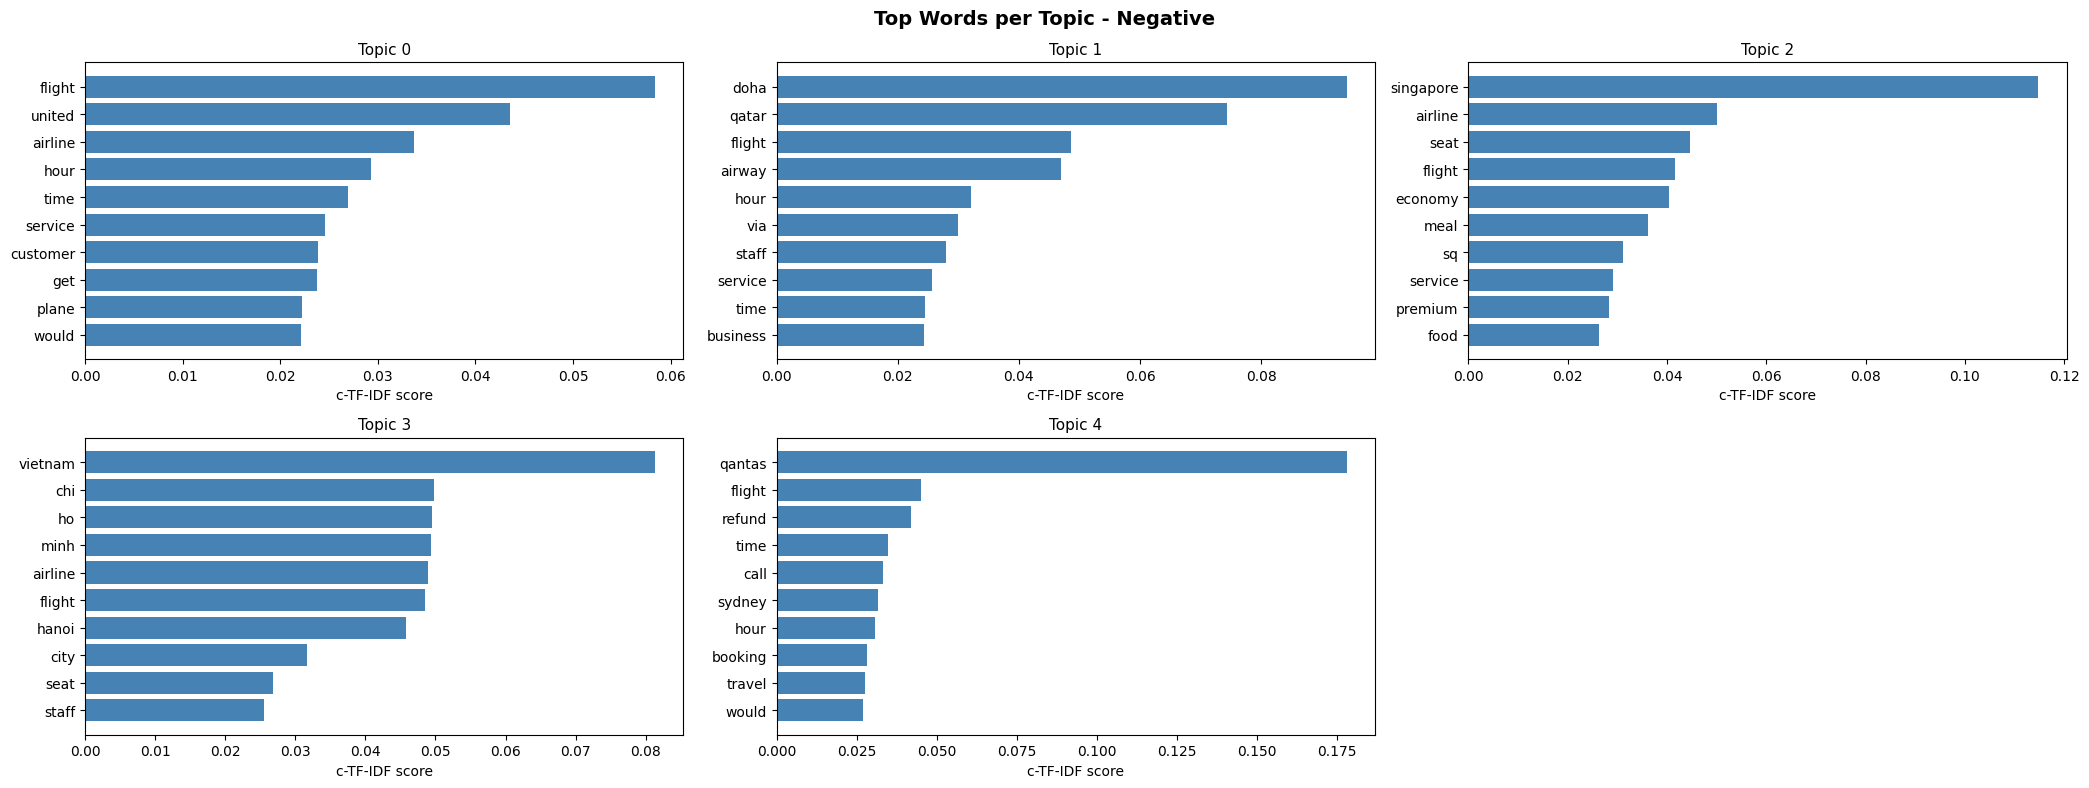

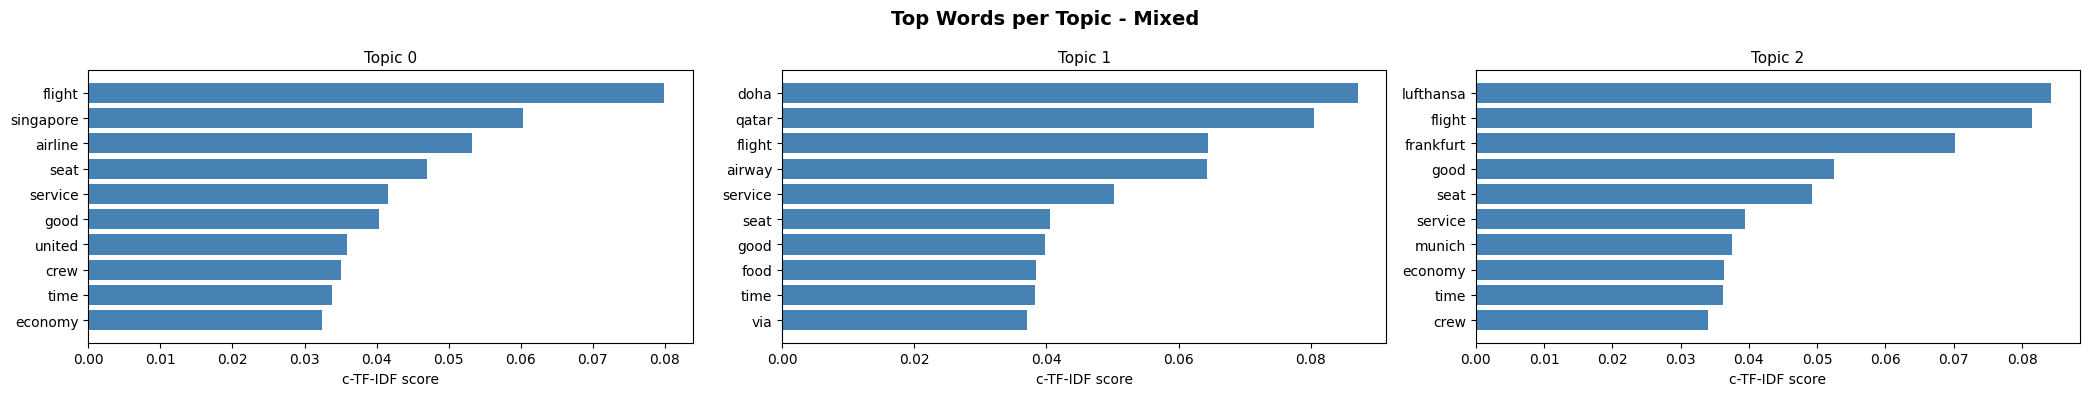

In [ ]:
# Top-Words Bar Charts
for sentiment, (model_t, _) in models_dict.items():
    plot_top_words(model_t, sentiment)


**Insight Generation & Analysis**

In [ ]:
# Dominant Topics per Sentiment
for sentiment, (model_t, _) in models_dict.items():
    print_dominant_topics(model_t, sentiment)



-- Dominant Topics - Positive --
  Topic   0 | Count   364 | doha, qatar, flight, seat, airway, good, food
  Topic   1 | Count   334 | united, flight, airline, seat, time, plane, hour
  Topic   2 | Count   322 | lufthansa, frankfurt, flight, seat, service, class, business
  Topic   3 | Count   207 | singapore, airline, flight, seat, crew, service, cabin
  Topic   4 | Count    75 | taipei, china, flight, airline, seat, good, food

-- Dominant Topics - Negative --
  Topic   0 | Count  2725 | flight, united, airline, hour, time, service, customer
  Topic   1 | Count   226 | doha, qatar, flight, airway, hour, via, staff
  Topic   2 | Count   215 | singapore, airline, seat, flight, economy, meal, sq
  Topic   3 | Count   155 | vietnam, chi, ho, minh, airline, flight, hanoi
  Topic   4 | Count    60 | qantas, flight, refund, time, call, sydney, hour

-- Dominant Topics - Mixed --
  Topic   0 | Count   879 | flight, singapore, airline, seat, service, good, united
  Topic   1 | Count   718 | 

-- Cross-Sentiment Summary --
          # Topics  Total Docs Assigned  Outlier Docs
Positive         7                 1364           117
Negative         6                 3431           156
Mixed            3                 2009             0


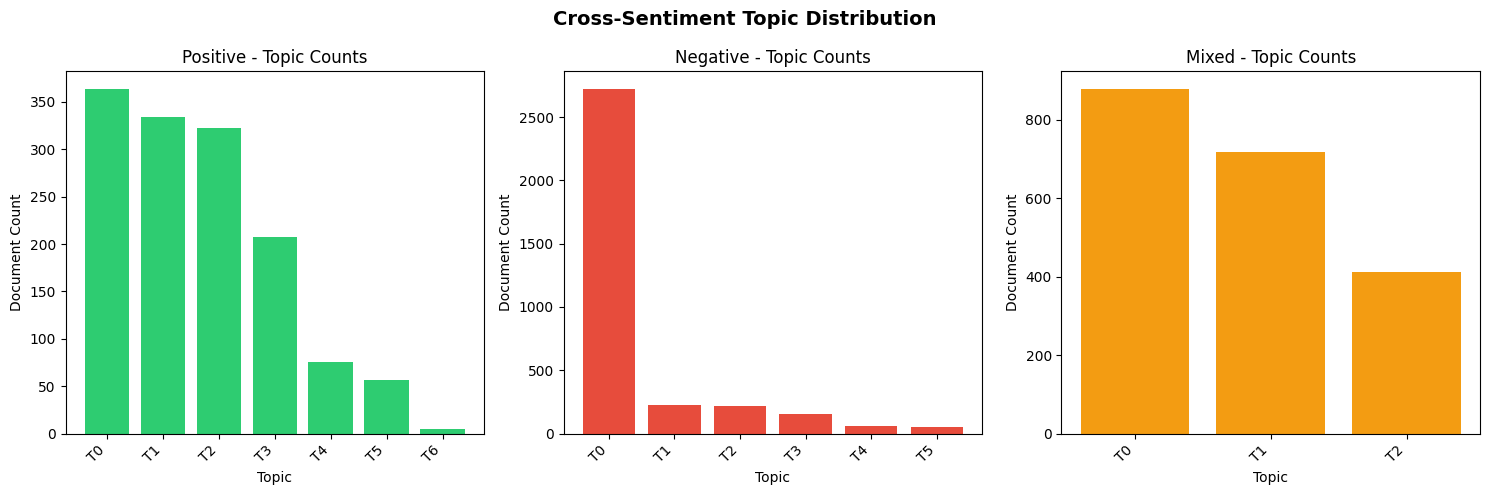

In [ ]:
# Cross-Sentiment Topic Distribution Comparison
summary_df = plot_cross_sentiment_distribution(models_dict)


In [ ]:
# Build DataFrames for each sentiment
df_positive = build_theme_df(topic_model_pos, pos_texts)
df_negative = build_theme_df(topic_model_neg, neg_texts)
df_mixed    = build_theme_df(topic_model_mix, mix_texts)


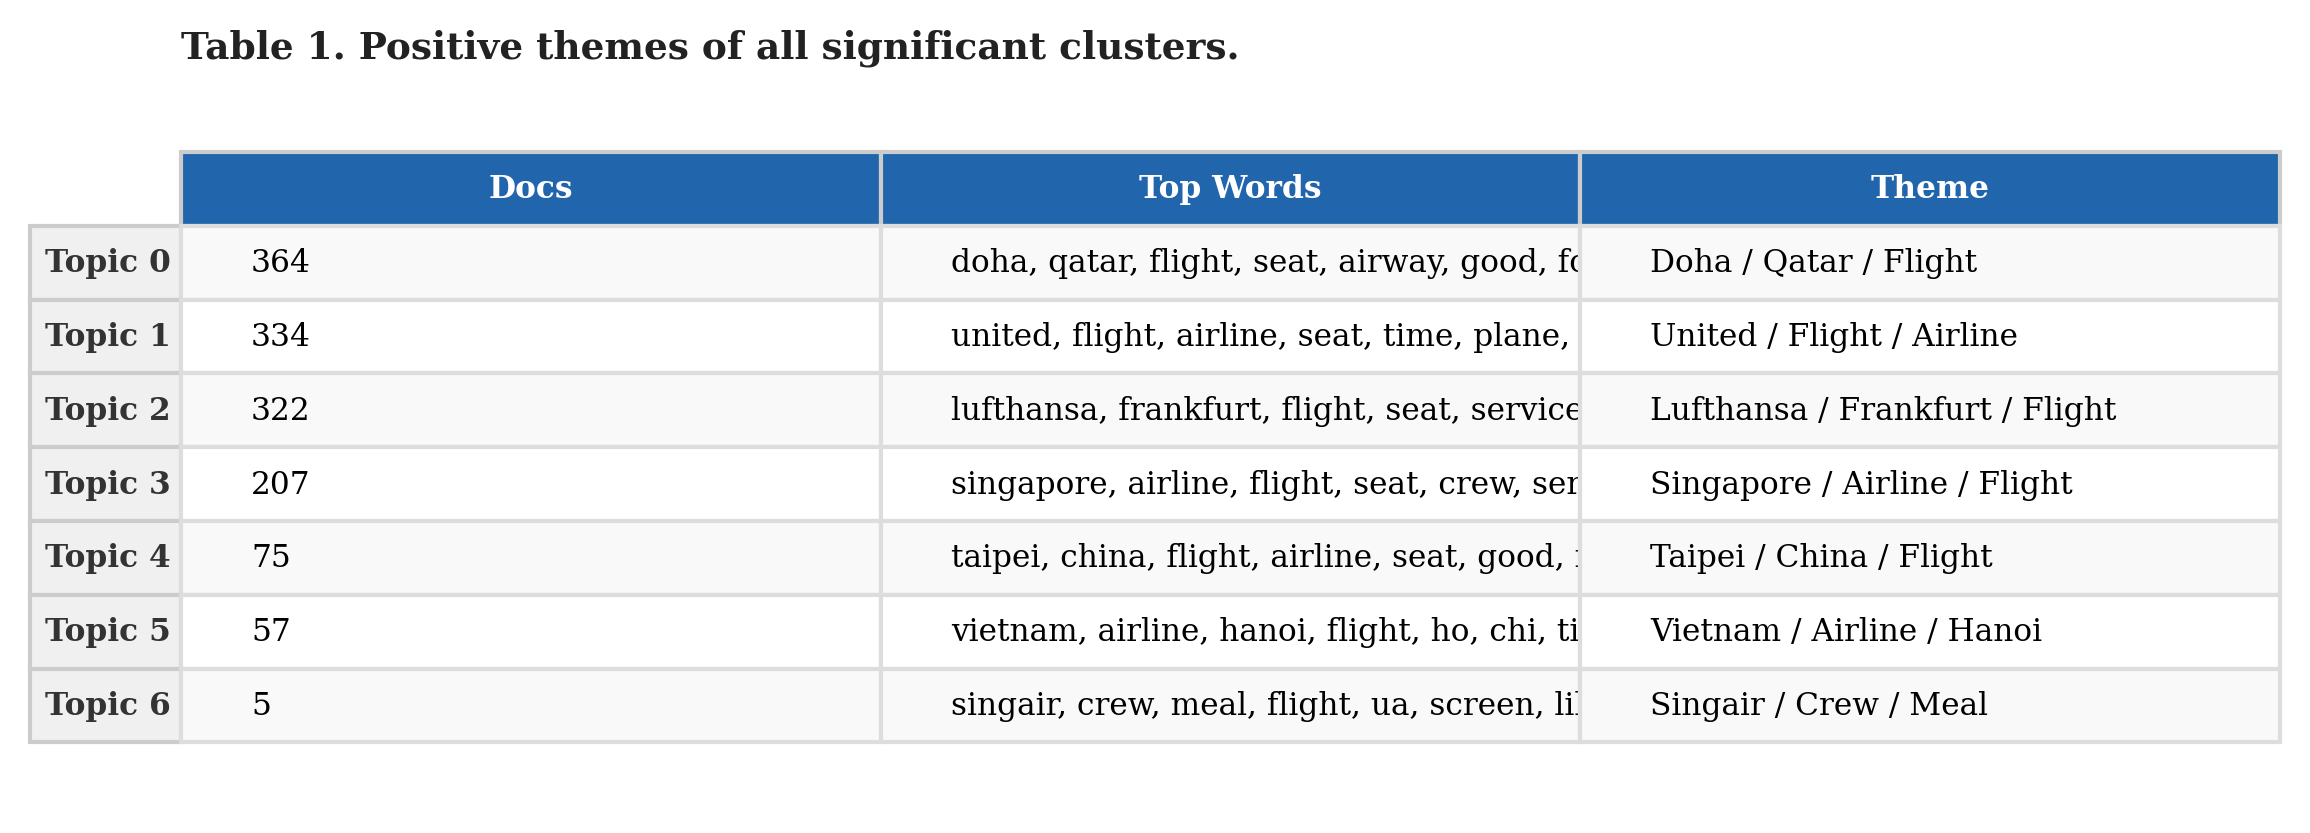

table_positive_themes saved ✓


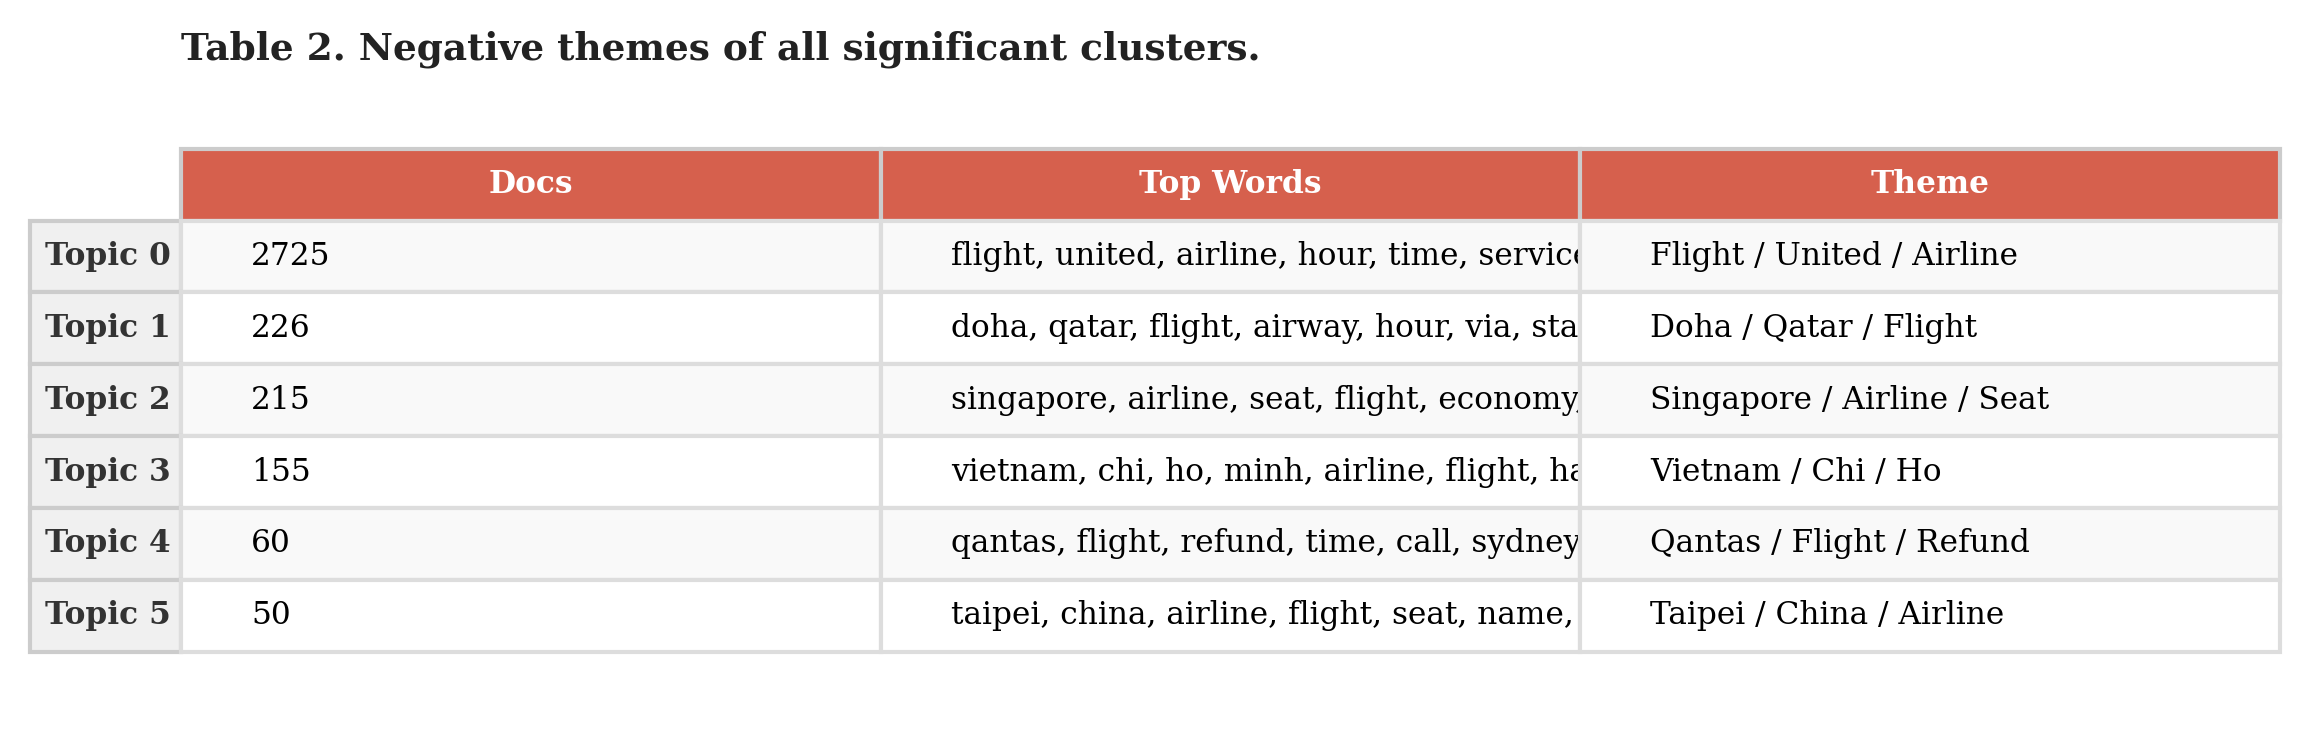

table_negative_themes saved ✓


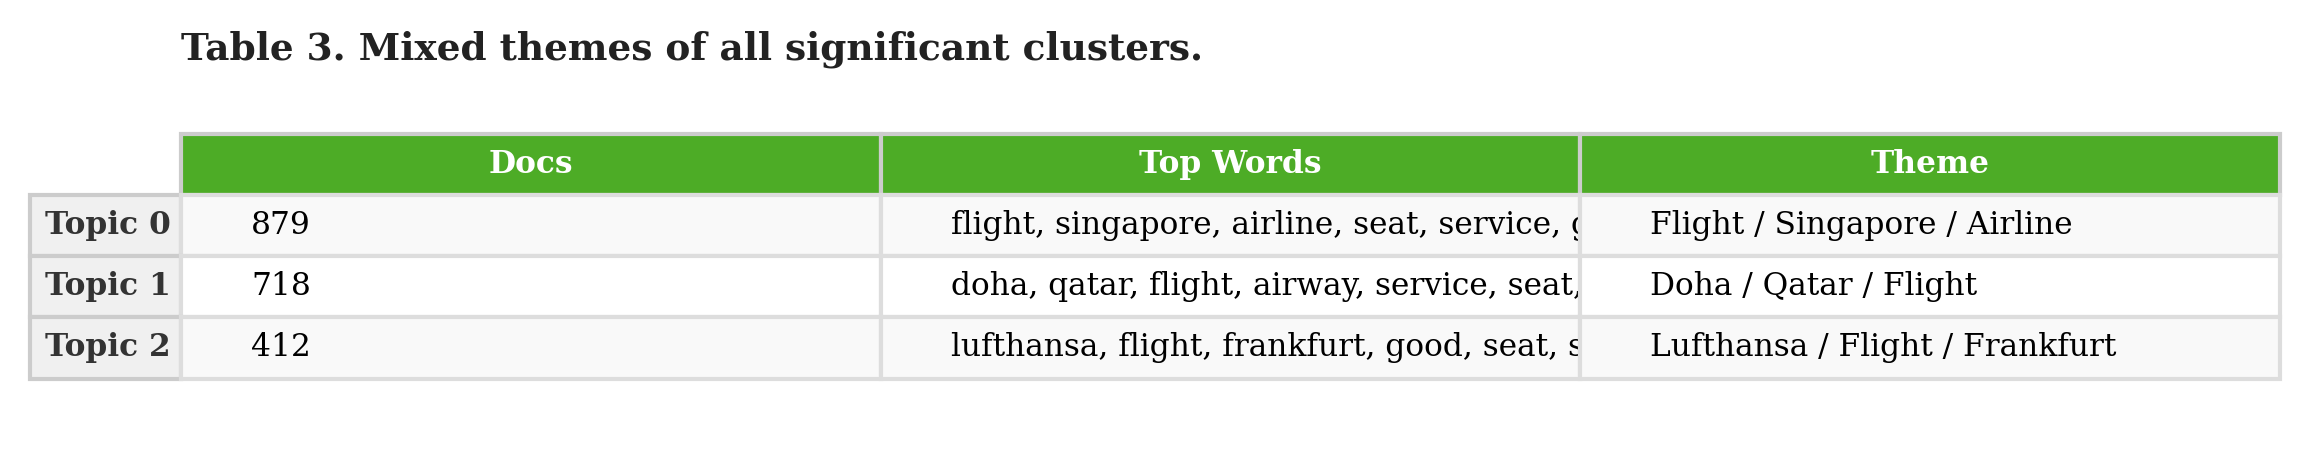

table_mixed_themes saved ✓


In [ ]:
plot_table(
    df_positive,
    title="Table 1. Positive themes of all significant clusters.",
    filename="table_positive_themes",
    header_color="#2166AC"   # blue
)

plot_table(
    df_negative,
    title="Table 2. Negative themes of all significant clusters.",
    filename="table_negative_themes",
    header_color="#D6604D"   # red
)

plot_table(
    df_mixed,
    title="Table 3. Mixed themes of all significant clusters.",
    filename="table_mixed_themes",
    header_color="#4DAC26"   # green
)

In [ ]:
# Key Insights & Patterns
all_insights = []
for sentiment, (model_t, _) in models_dict.items():
    all_insights.extend(extract_insights(model_t, sentiment))

insights_df = pd.DataFrame(all_insights)
print(insights_df.to_string(index=False))


Sentiment  Topic  Doc Count  % Share                                   Key Words
 Positive      0        364     35.7           doha, qatar, flight, seat, airway
 Positive      1        334     32.7         united, flight, airline, seat, time
 Positive      2        322     31.6 lufthansa, frankfurt, flight, seat, service
 Negative      0       2725     86.1         flight, united, airline, hour, time
 Negative      1        226      7.1           doha, qatar, flight, airway, hour
 Negative      2        215      6.8   singapore, airline, seat, flight, economy
    Mixed      0        879     43.8   flight, singapore, airline, seat, service
    Mixed      1        718     35.7        doha, qatar, flight, airway, service
    Mixed      2        412     20.5    lufthansa, flight, frankfurt, good, seat


In [ ]:
# Generate & Save Final Report
generate_report(eval_df, models_dict, insights_df)


  SENTIMENT-AWARE TOPIC ANALYSIS REPORT

[1] TOPIC MODEL QUALITY METRICS
          Coherence (C_V)  Diversity  Silhouette  # Topics
Positive           0.4912     0.5571      0.5897       7.0
Negative           0.4882     0.6500      0.3250       6.0
Mixed              0.4324     0.6000      0.5898       2.0

[2] DOMINANT TOPICS - POSITIVE
  Topic   0: doha, qatar, flight, seat, airway, good  (n=364)
  Topic   1: united, flight, airline, seat, time, plane  (n=334)
  Topic   2: lufthansa, frankfurt, flight, seat, service, class  (n=322)
  Topic   3: singapore, airline, flight, seat, crew, service  (n=207)
  Topic   4: taipei, china, flight, airline, seat, good  (n=75)

[2] DOMINANT TOPICS - NEGATIVE
  Topic   0: flight, united, airline, hour, time, service  (n=2725)
  Topic   1: doha, qatar, flight, airway, hour, via  (n=226)
  Topic   2: singapore, airline, seat, flight, economy, meal  (n=215)
  Topic   3: vietnam, chi, ho, minh, airline, flight  (n=155)
  Topic   4: qantas, flight, ref